In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
hour_data = pd.read_csv("../data/raw/hour.csv")
#day_data = pd.read_csv("../data/raw/day.csv")

In [8]:
# Print first 10 rows to see data 
print(hour_data.head(10))

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   
5        6  2011-01-01       1   0     1   5        0        6           0   
6        7  2011-01-01       1   0     1   6        0        6           0   
7        8  2011-01-01       1   0     1   7        0        6           0   
8        9  2011-01-01       1   0     1   8        0        6           0   
9       10  2011-01-01       1   0     1   9        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81     0.0000       3          13   16

Initial observations
Below it can be seen all columns with their types; main analysis of data; cnt for each hour in bike rental. 
'cnt' variable represents total number of bike rentals for hour

In [9]:
# Print all columns and data types
print(hour_data.dtypes)

print(hour_data.describe())

hour_demand = hour_data.groupby("hr")["cnt"].mean()
print(hour_demand)

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object
          instant        season            yr          mnth            hr  \
count  17379.0000  17379.000000  17379.000000  17379.000000  17379.000000   
mean    8690.0000      2.501640      0.502561      6.537775     11.546752   
std     5017.0295      1.106918      0.500008      3.438776      6.914405   
min        1.0000      1.000000      0.000000      1.000000      0.000000   
25%     4345.5000      2.000000      0.000000      4.000000      6.000000   
50%     8690.0000      3.000000      1.000000      7.000000     12.000000   
75%    13034.5000      3.000000      1.000000     10.000000     18.000000

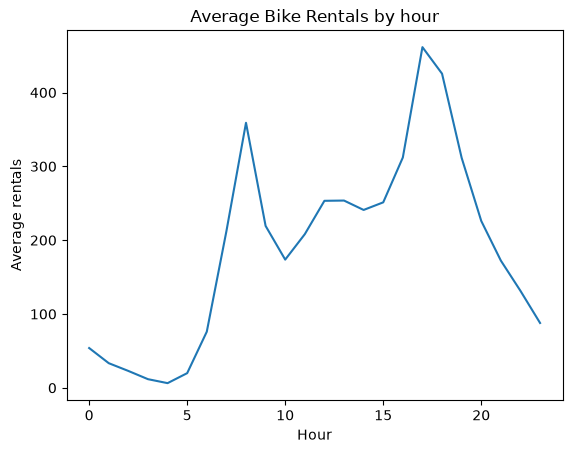

In [10]:
hour_demand.plot()
plt.xlabel("Hour")
plt.ylabel("Average rentals")
plt.title("Average Bike Rentals by hour")
plt.show()

On the graph above it is obvious that the most popular time for bike rent is around 17-18 and it reaches 400+ bikes. The least bikes people rent at 4-5 o'clock

weekday
0    177.468825
1    183.744655
2    191.238891
3    191.130505
4    196.436665
5    196.135907
6    190.209793
Name: cnt, dtype: float64


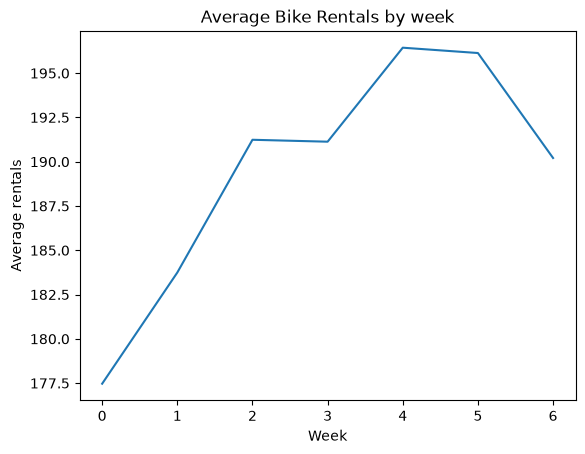

In [11]:
weekday_demand = hour_data.groupby("weekday")["cnt"].mean()
print(weekday_demand)

weekday_demand.plot()
plt.xlabel("Week")
plt.ylabel("Average rentals")
plt.title("Average Bike Rentals by week")
plt.show()

Graph that is over here shows 7 days* of rental. Many bikes are rented by the end of the week, from Friday to Saturday.
* 0-Monday, 1-Tuesday, 2-Wednesday, 3-Thursday, 4-Friday, 5-Saturday, 6-Sunday

workingday
0    181.405332
1    193.207754
Name: cnt, dtype: float64


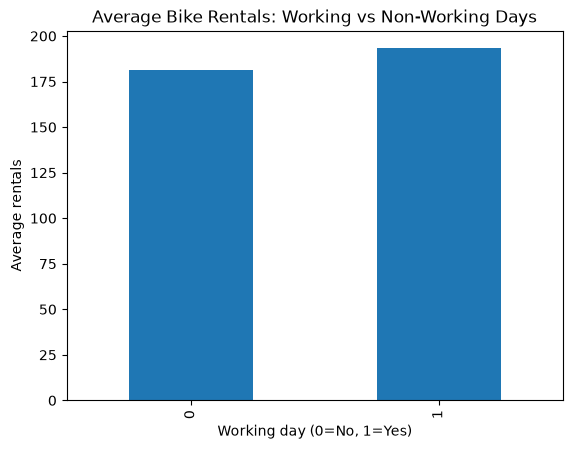

In [12]:
workingday_demand = hour_data.groupby("workingday")["cnt"].mean()
print(workingday_demand)
workingday_demand.plot(kind="bar")
plt.xlabel("Working day (0=No, 1=Yes)")
plt.ylabel("Average rentals")
plt.title("Average Bike Rentals: Working vs Non-Working Days")
plt.show()

It is shown that the rental in working and non-working days are almost the same. It varies from 175 to 190 bikes.

holiday
0    190.42858
1    156.87000
Name: cnt, dtype: float64


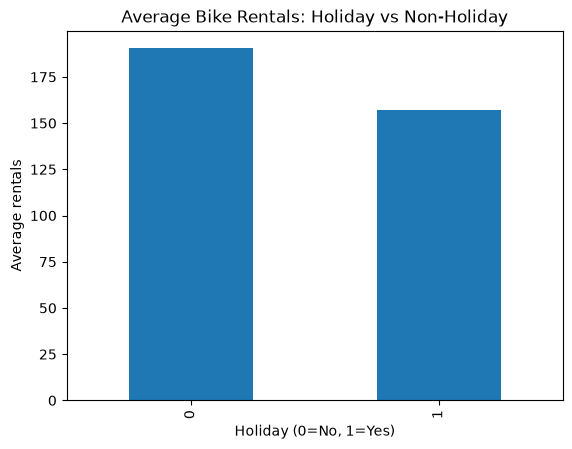

In [13]:
holiday_demand = hour_data.groupby("holiday")["cnt"].mean()
print(holiday_demand)
holiday_demand.plot(kind="bar")
plt.xlabel("Holiday (0=No, 1=Yes)")
plt.ylabel("Average rentals")
plt.title("Average Bike Rentals: Holiday vs Non-Holiday")
plt.show()

Bar represents that in non-holiday day people use bike rental more than in holidays. 

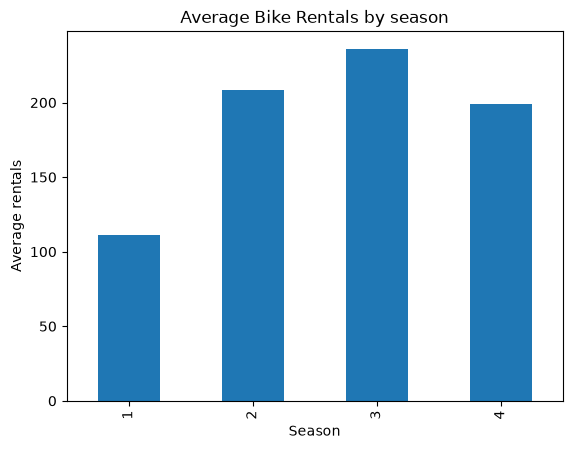

In [14]:
season_demand = hour_data.groupby("season")["cnt"].mean()
season_demand.plot(kind="bar")
plt.xlabel("Season")
plt.ylabel("Average rentals")
plt.title("Average Bike Rentals by season")
plt.show()

For seasons as it was expected that the most rentals were in seasons 2,3,4.
1-spring, 2-summer, 3-autumn, 4-winter

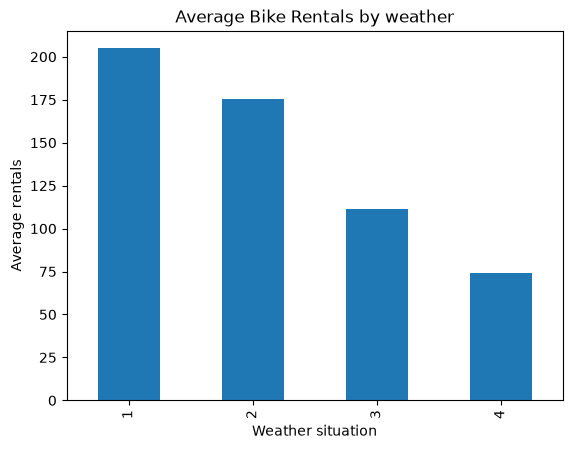

In [15]:
weather_demand=hour_data.groupby("weathersit")["cnt"].mean()
weather_demand.plot(kind="bar")
plt.xlabel("Weather situation")
plt.ylabel("Average rentals")
plt.title("Average Bike Rentals by weather")
plt.show()

It was obvious that in nice weather it will be more rental usage. 
1-sunny, 2-cloudy, 3-light rain, drizzle, 4-heavy rain

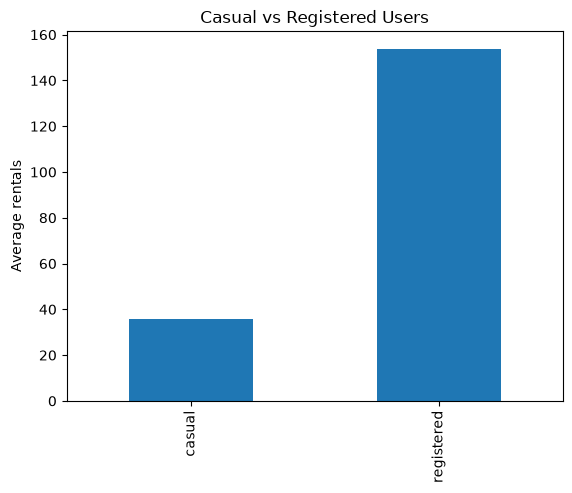

In [16]:
hour_data[["casual", "registered", "cnt"]].mean()
user_demand=hour_data[["casual", "registered"]].mean()
user_demand.plot(kind="bar")
plt.ylabel("Average rentals")
plt.title("Casual vs Registered Users")
plt.show()

More registered users use rental than casual. The difference reaches 4 times. 

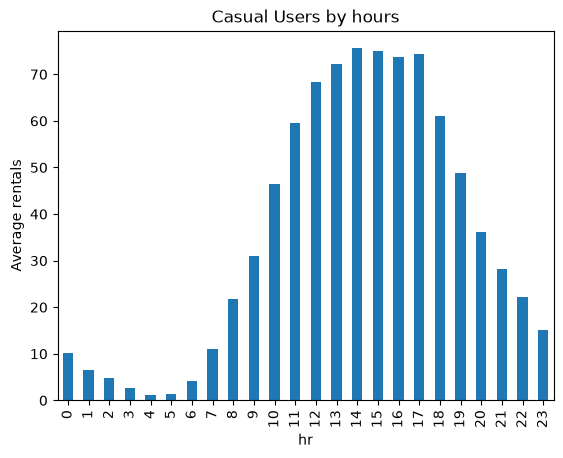

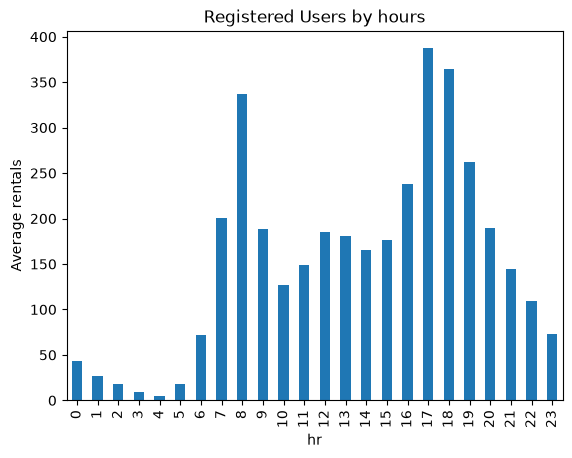

In [17]:
casual_by_hour=hour_data.groupby("hr")["casual"].mean()
casual_by_hour.plot(kind="bar")
plt.ylabel("Average rentals")
plt.title("Casual Users by hours")
plt.show()

registered_by_hour=hour_data.groupby("hr")["registered"].mean()
registered_by_hour.plot(kind="bar")
plt.ylabel("Average rentals")
plt.title("Registered Users by hours")
plt.show()



From 2 plots we see different hours for registered and casual users. Casual users use after second part of the day while demand from registered users increase in the morning hours and evening.

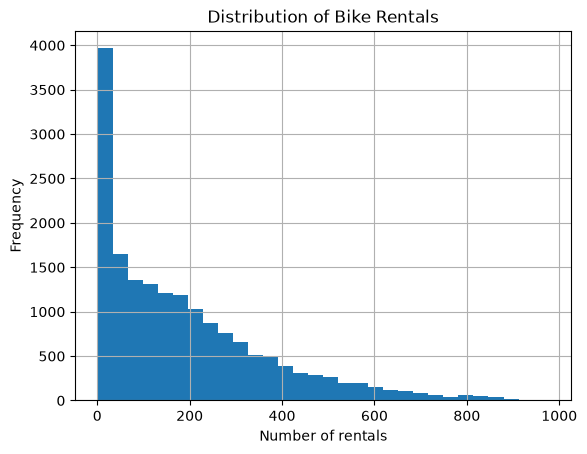

In [18]:
hour_data["cnt"].hist(bins=30)
plt.xlabel("Number of rentals")
plt.ylabel("Frequency")
plt.title("Distribution of Bike Rentals")
plt.show()

In [19]:
print("Mean:", hour_data["cnt"].mean())
print("Median:", hour_data["cnt"].median())
print("Standard deviation:", hour_data["cnt"].std())
print("Min:", hour_data["cnt"].min())
print("Max:", hour_data["cnt"].max())

Mean: 189.46308763450142
Median: 142.0
Standard deviation: 181.38759909186473
Min: 1
Max: 977


The graph and results showed that distribution is right-skewed. Also high standart deciation mean that at night people use less rental than at daytime. 

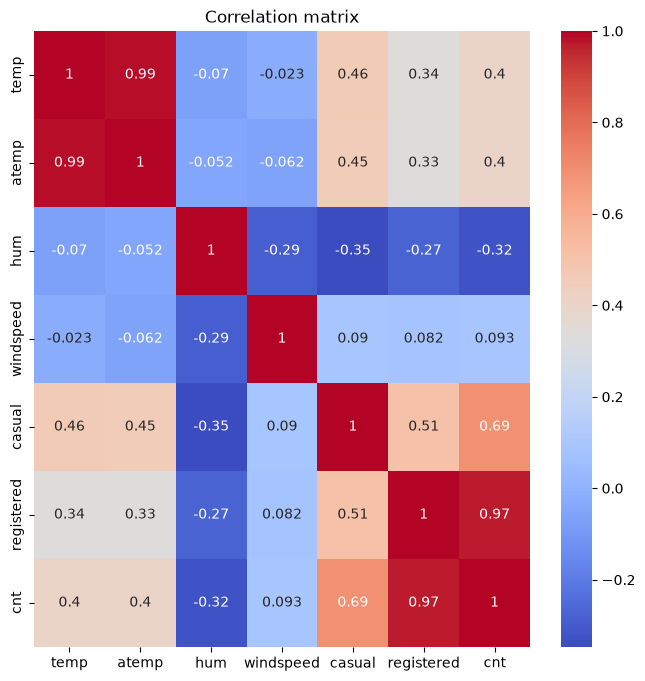

In [22]:
numerical = [
        "temp",
        "atemp",
        "hum",
        "windspeed",
        "casual",
        "registered",
        "cnt",
    ]

cor=hour_data[numerical].corr()
plt.figure(figsize=(8,8))
sns.heatmap(cor, annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

It was logical that correlation between registered, casual and cnt will be the highest because they are mathematically connected. Also it is observed that wind speen doesn't have effect on cnt. But the figure of hum can show that the demand of rent is lower in such conditions.